![IITIS](pictures/logoIITISduze.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from typing import Optional, Callable, Union

def calculate_energy_ising(J: np.ndarray, h: np.ndarray, state):
    state = state.T
    return state @ J @ state.T + h @ state.T


def simulated_bifurcation(J, h, num_steps, time_step, M, trajectories, 
                          K: Optional[float] = None, delta: Optional[float] = None, xi_0: Union[Callable, float, None] = None):
    # Ustawianie parametrów
    K = 1
    delta = 1
    small_delta_t = time_step/M
    N = len(h)
    sigma = 1   # sigma = np.std(J.flatten())
    xi_0 = 0.7 * time_step / sigma * sqrt(N)
    #xi_0 = 0.1
   
    # Iniclizacja
    # x = np.random.uniform(-0.1, 0.1, (N, trajectories))
    x = np.zeros((N, trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, trajectories))
    #y = np.zeros((N, trajectories))
    p = np.linspace(0, 1, num=num_steps)

    x_1_history = []
    y_1_history = []
    timeline = np.array(list(range(num_steps)))

    for t in range(num_steps):
        x += delta * y * time_step
        y -= (K * np.power(x, 3) + (delta - p[t]) * x - xi_0 * J @ x) * time_step

        # x_m = x
        # y_m = y

        # for _ in range(M):
        #     x_m += delta * y_m * small_delta_t
        #     y_m -= (K * np.power(x_m, 3) + (delta - p[t + 1]) * x_m) * small_delta_t

        # x = x_m
        # y = y_m + xi_0 * J @ x * time_step
        x_1_history.append(x[0, 0])
        y_1_history.append(y[0, 0])
        

    
    plt.plot(timeline, x_1_history)
    plt.plot(timeline, y_1_history)
    plt.ylim(-1.5, 1.5)
    plt.legend(["x_i", "y_i"])
    plt.xlabel("t")
    plt.show()
    solution = np.sign(x)
    return solution, -0.5 * solution.T @ J @ solution

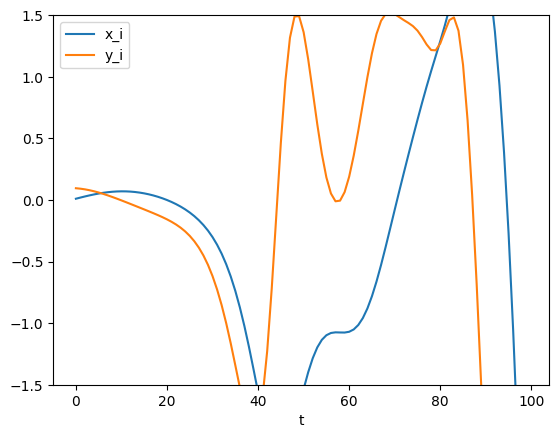

[[-52.]]


In [49]:
import os
import pandas as pd
# J = np.triu(np.random.uniform(-1, 1, (n, n))) # losowa gęsta macierz górnotrójkątna
# np.fill_diagonal(J, 0.0)

def read_instance(path: os.PathLike):
    df = pd.read_csv(path, sep=" ", header=None, comment="#", names=["i", "j", "value"])

    n = max(df[["i", "j"]].max())
    h = np.zeros(n)
    J = np.zeros((n, n))
    
    for row in df.itertuples():
        if row.i == row.j:
            h[row.i - 1] = row.value
        elif row.i > row.j:
            J[row.j - 1, row.i - 1] = row.value  # by zachować górnotrójkątność
        else:
            J[row.i - 1, row.j - 1] = row.value
            
    return J, h

instance_path = os.path.join("instancje", "Pegasus", "P4_CBFM-P.txt")
J, h = read_instance(instance_path)
nstep = 100
time_step = 0.1
M = 4

_, energy = simulated_bifurcation(J, h, nstep, time_step, M, 1)

print(energy)

In [169]:
# balistic simulated bifuraction

# def calculate_energy_column(J: np.ndarray, h: np.ndarray, state: np.ndarray, num_trajectories: int):
#     hamiltonian = np.zeros(num_trajectories)
#     for t in range(num_trajectories):
#         hamiltonian[t] = state[:, t].T @ J @ state[:, t] + state[:, t].T @ h
#     #return state.T @ J @ state + state.T @ h
#     return hamiltonian

def calculate_energy_parrarel(J: np.ndarray, h: np.ndarray, state: np.ndarray):
    # Zakładamy, że J jest górnotrójkątna z 0 na przekątnej
    
    return np.sum(state * (J @ state + h.reshape(len(h), 1)), axis=0)




def wall(x:np.ndarray, y:np.ndarray):
    #TODO: Probably can be implemented more efficient
    with np.nditer(x, flags=['multi_index'], op_flags=['readwrite']) as it:
        for a in it:
            i, j = it.multi_index
            if np.abs(a) > 1:
                x[i, j] = np.sign(a)
                y[i, j] = 0
    return x, y


def balistic_simulated_bifurcation(J, h, num_steps, time_step, num_trajectories: int, 
                                   a_0: Optional[float] = None, c_0: Optional[float] = None):
    if a_0 is None:
        a_0 = 1
    if c_0 is None:
        c_0 = 0.1

    N = len(h)
    a = np.linspace(0, a_0, num=num_steps)

    x = np.zeros((N, num_trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, num_trajectories))

    for t in range(num_steps):
        y += (-1 * (a_0 - a[t]) * x + c_0 * J @ x) * time_step  # x(t)
        x += a_0 * y * time_step # x(t + 1)

        x, y = wall(x, y)

    x = np.sign(x)
    return x, calculate_energy_parrarel(J, h, x)



In [172]:
import os
import pandas as pd

def read_instance(path: os.PathLike):
    df = pd.read_csv(path, sep=" ", header=None, comment="#", names=["i", "j", "value"])

    n = max(df[["i", "j"]].max())
    h = np.zeros(n)
    J = np.zeros((n, n))
    
    for row in df.itertuples():
        if row.i == row.j:
            h[row.i - 1] = row.value
        elif row.i > row.j:
            J[row.j - 1, row.i - 1] = row.value  # by zachować górnotrójkątność
        else:
            J[row.i - 1, row.j - 1] = row.value
            
    return J, h


instance_path = os.path.join("instancje", "Pegasus", "P4_CBFM-P.txt")


J, h = read_instance(instance_path)
state, en = balistic_simulated_bifurcation(J, h, num_steps=1000, time_step=0.5, num_trajectories=34)
print(en)


[213. 183. 187. 247. 149. 235. 157. 139. 173. 303.]


In [171]:
import numpy as np

N = 100
J = np.zeros((N, N))
np.fill_diagonal(J[:-1, 1:], 1.0)
h = np.zeros(N)
state, en = balistic_simulated_bifurcation(J, h, num_steps=100, time_step=0.75, num_trajectories=34)

print(en)

[-11. -23.  -7. -21. -25. -13. -15. -13. -13. -25. -13. -23.  -9. -19.
 -11. -21.  -3. -17. -29. -11.  -7. -11. -11. -15. -11. -23. -25. -23.
 -21.  -7. -17.  -9. -17. -23.]


In [173]:
def discrete_simulated_bifurcation(J, h, num_steps, time_step, num_trajectories: int, 
                                   a_0: Optional[float] = None, c_0: Optional[float] = None):
    if a_0 is None:
        a_0 = 1
    if c_0 is None:
        c_0 = 0.1

    N = len(h)
    a = np.linspace(0, a_0, num=num_steps)

    x = np.zeros((N, num_trajectories))
    y = np.random.uniform(-0.1, 0.1, (N, num_trajectories))

    for t in range(num_steps):
        y += (-1 * (a_0 - a[t]) * x + c_0 * J @ np.sign(x)) * time_step  # y(t+1); x(t), x(t)
        x += a_0 * y * time_step # x(t + 1); y(t+1)

        x, y = wall(x, y)

    x = np.sign(x)
    return x, calculate_energy_parrarel(J, h, x)


In [ ]:
# Self conained 2 qubit implementation

import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

def calculate_energy_ising(J: np.ndarray, h: np.ndarray, state):
    state = state.T
    return state @ J @ state.T + h @ state.T



def simulated_bifurcation(J, h, time, time_step, M, trajectories):
    # Ustawianie parametrów
    K = 1
    delta = 0.5 # delta = 1
    small_delta_t = time_step/M
    N = len(h)
    sigma = np.std(J.flatten())
    #xi_0 = 0.7 * time_step / sigma * sqrt(N)
    xi_0 = 0.1
    num_steps = int(time / time_step)
    
   

    # Iniclizacja
    # x = np.random.uniform(-0.1, 0.1, (N, trajectories))
    x = np.zeros((N, trajectories))
    #y = np.random.uniform(-0.1, 0.1, (N, trajectories))
    y = np.array([[0], [0.1]])
    p = np.linspace(0, 2, num=num_steps + 1)

    x_1_history = []
    y_1_history = []
    timeline = np.array([t*time_step for t in range(num_steps + 1)])

    for p_t in p:
        x += delta * y * time_step
        y -= (K * np.power(x, 3) + (delta - p_t) * x - xi_0 * J @ x) * time_step
        x_1_history.append(x[0, 0])
        y_1_history.append(y[0, 0])
        # x_m = x
        # y_m = y

        # for _ in range(M):
        #     x_m += delta * y_m * small_delta_t
        #     y_m -= (np.power(x_m, 2) + (delta - p_t) * x_m) * small_delta_t

        # x = x_m
        # y = y_m + xi_0 * J @ x * time_step
        

    
    plt.plot(timeline, x_1_history)
    plt.plot(timeline, y_1_history)
    plt.ylim(-1.5, 1.5)
    plt.legend(["x_1", "y_1"])
    plt.ylabel("t")
    plt.show()
    solution = np.sign(x)
    return solution, -0.5 * solution.T @ J @ solution



n = 2


# J = np.triu(np.random.uniform(-1, 1, (n, n))) # losowa gęsta macierz górnotrójkątna
# np.fill_diagonal(J, 0.0)

J = np.triu(np.ones((n, n)))
np.fill_diagonal(J, 0.0)
h = np.zeros(n)
# from dimod import BinaryQuadraticModel
# from dwave.samplers import SimulatedAnnealingSampler

# bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
# sampler= SimulatedAnnealingSampler()
# sampleset = sampler.sample(bqm_instance, num_reads=1)
# print(sampleset)

time = 400
time_step = 0.001
M = 2

simulated_bifurcation(J, h, time, time_step, M, 1)